In [1]:
# ============================================
# FSI v1.0b — Pre-Calving Mastitis Risk
# Predicting post-calving SCC elevation
# from previous lactation history
# Based on Thompson et al. 2023 methodology
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report,
                             balanced_accuracy_score,
                             roc_auc_score,
                             confusion_matrix)
from sklearn.metrics import make_scorer, f1_score
import shap
import warnings
warnings.filterwarnings('ignore')

print("FSI v1.0b — Pre-Calving Risk Prediction")
print("Libraries loaded successfully")

FSI v1.0b — Pre-Calving Risk Prediction
Libraries loaded successfully


In [2]:
# ============================================
# FSI v1.0b — Load Data
# ============================================

df = pd.read_csv('synthetic_thompson2023_postcalving_scc_10000.csv')

print("Data loaded successfully")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Data loaded successfully
Shape: (10000, 39)

First 5 rows:
  cow_lactation_id     cow_id   herd_id  parity_prior_lactation  \
0         CL-00001  COW-00001  HERD-004                       4   
1         CL-00002  COW-00001  HERD-062                       3   
2         CL-00003  COW-00002  HERD-051                       4   
3         CL-00004  COW-00002  HERD-013                       1   
4         CL-00005  COW-00003  HERD-072                       2   

   n_scc_records_previous_lactation  dry_off_scc_missing  \
0                                10                    0   
1                                 9                    0   
2                                 8                    0   
3                                10                    0   
4                                 7                    0   

   dry_off_clinical_mastitis_within_7d  dry_off_imi_status_paper_rule  \
0                                    0                              0   
1                              

CLASS DISTRIBUTION:
raised_scc_post_calving_paper_rule
0    8298
1    1702
Name: count, dtype: int64

CLASS PERCENTAGE:
raised_scc_post_calving_paper_rule
0    83.0
1    17.0
Name: proportion, dtype: float64

MISSING VALUES:
last_scc_prev_lactation_cells_ml    345
dtype: int64

KEY STATISTICS BY CLASS:
                                    median_scc_prev_lactation_cells_ml  \
raised_scc_post_calving_paper_rule                                       
0                                                            117705.08   
1                                                            236864.04   

                                    pct_scc_gt_200k_prev_lactation  \
raised_scc_post_calving_paper_rule                                   
0                                                            19.35   
1                                                            46.68   

                                    dry_off_imi_status_paper_rule  \
raised_scc_post_calving_paper_rule               

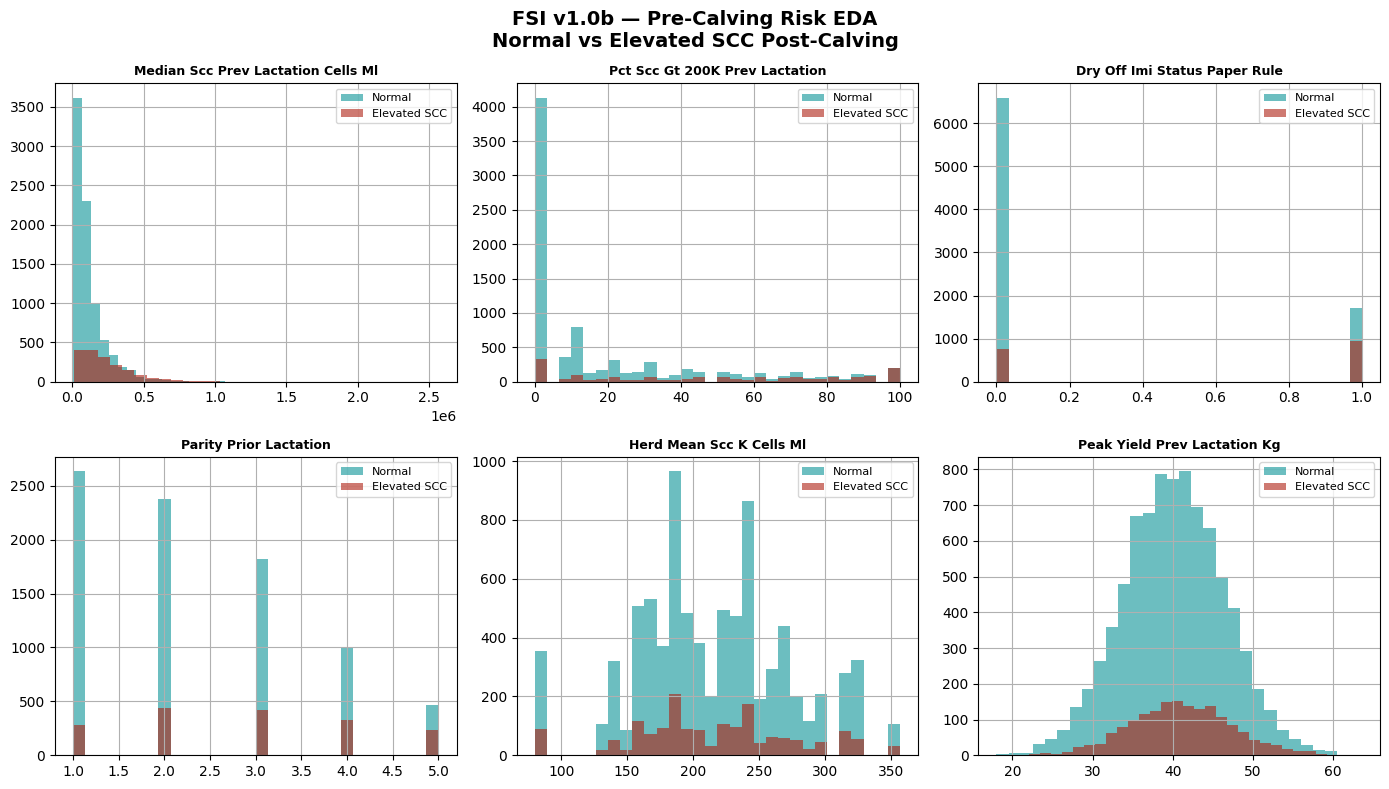

EDA saved


In [3]:
# ============================================
# FSI v1.0b — EDA
# ============================================

# Target variable
print("CLASS DISTRIBUTION:")
print(df['raised_scc_post_calving_paper_rule'].value_counts())
print("\nCLASS PERCENTAGE:")
print(df['raised_scc_post_calving_paper_rule'].value_counts(
      normalize=True).mul(100).round(1))

print("\nMISSING VALUES:")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("No missing values")

print("\nKEY STATISTICS BY CLASS:")
key_features = [
    'median_scc_prev_lactation_cells_ml',
    'pct_scc_gt_200k_prev_lactation',
    'dry_off_imi_status_paper_rule',
    'parity_prior_lactation',
    'herd_mean_scc_k_cells_ml',
    'peak_yield_prev_lactation_kg'
]
print(df.groupby('raised_scc_post_calving_paper_rule')[key_features].mean().round(2))

# Visualise
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('FSI v1.0b — Pre-Calving Risk EDA\nNormal vs Elevated SCC Post-Calving',
             fontsize=14, fontweight='bold')

for i, feat in enumerate(key_features):
    ax = axes[i//3, i%3]
    df[df['raised_scc_post_calving_paper_rule']==0][feat].hist(
        ax=ax, alpha=0.6, color='#0A9396', label='Normal', bins=30)
    df[df['raised_scc_post_calving_paper_rule']==1][feat].hist(
        ax=ax, alpha=0.6, color='#AE2012', label='Elevated SCC', bins=30)
    ax.set_title(feat.replace('_',' ').title(), fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('FSI_v1b_EDA.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("EDA saved")

In [4]:
# ============================================
# FSI v1.0b — Preprocessing & Model
# ============================================

# Drop identifier columns and leakage columns
drop_cols = [
    'cow_lactation_id',
    'cow_id',
    'herd_id',
    # These are measured POST calving — leakage
    'post_calving_scc_cells_ml',
    'post_calving_scc_threshold_used_cells_ml',
    'post_calving_sample_day',
    'clinical_mastitis_within_30d_post_calving',
    'normal_scc_post_calving_paper_rule',
    # Target
    'raised_scc_post_calving_paper_rule'
]

X = df.drop(columns=drop_cols)
y = df['raised_scc_post_calving_paper_rule']

print("Features:", X.columns.tolist())
print("Shape:", X.shape)

# Handle missing values — median imputation
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print(f"\nMissing values after imputation: {X_imputed.isnull().sum().sum()}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"Scale pos weight: {scale:.2f}")
print(f"Training: {X_train.shape}")
print(f"Test: {X_test.shape}")

# XGBoost
xgb_b = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

print("\nTraining FSI v1.0b pre-calving model...")
xgb_b.fit(X_train, y_train)
print("Done!")

y_pred = xgb_b.predict(X_test)
y_proba = xgb_b.predict_proba(X_test)[:,1]

print("\n============================================")
print("FSI v1.0b — Pre-Calving Risk Results")
print("============================================")
print(classification_report(y_test, y_pred,
      target_names=['Normal SCC','Elevated SCC']))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred),4))
print("AUC-ROC:", round(roc_auc_score(y_test, y_proba),4))

Features: ['parity_prior_lactation', 'n_scc_records_previous_lactation', 'dry_off_scc_missing', 'dry_off_clinical_mastitis_within_7d', 'dry_off_imi_status_paper_rule', 'calving_interval_days', 'lactation_length_days', 'month_of_dry_off', 'month_of_calving', 'first_scc_prev_lactation_cells_ml', 'median_scc_prev_lactation_cells_ml', 'mean_scc_prev_lactation_cells_ml', 'min_scc_prev_lactation_cells_ml', 'max_scc_prev_lactation_cells_ml', 'mean_first3_scc_prev_lactation_cells_ml', 'mean_last3_scc_prev_lactation_cells_ml', 'ratio_last3_to_first3_scc', 'last_scc_prev_lactation_cells_ml', 'consecutive_3_scc_gt_200k_prev_lactation', 'pct_scc_lt_50k_prev_lactation', 'pct_scc_gt_100k_prev_lactation', 'pct_scc_gt_200k_prev_lactation', 'pct_scc_gt_400k_prev_lactation', 'pct_scc_gt_1000k_prev_lactation', 'peak_yield_prev_lactation_kg', 'yield_at_last_recording_kg', 'herd_new_dry_period_imi_6mo_rate', 'herd_new_dry_period_imi_year_rate', 'herd_mean_scc_k_cells_ml', 'herd_predicted_305d_yield_l']
Sha

TOP 10 FEATURE IMPORTANCES:
                               feature  importance
        pct_scc_gt_100k_prev_lactation    0.350967
         dry_off_imi_status_paper_rule    0.095703
      last_scc_prev_lactation_cells_ml    0.028661
                parity_prior_lactation    0.027152
        pct_scc_gt_200k_prev_lactation    0.026776
         pct_scc_lt_50k_prev_lactation    0.025788
      mean_scc_prev_lactation_cells_ml    0.024886
     herd_new_dry_period_imi_year_rate    0.023382
mean_last3_scc_prev_lactation_cells_ml    0.020908
            yield_at_last_recording_kg    0.020820


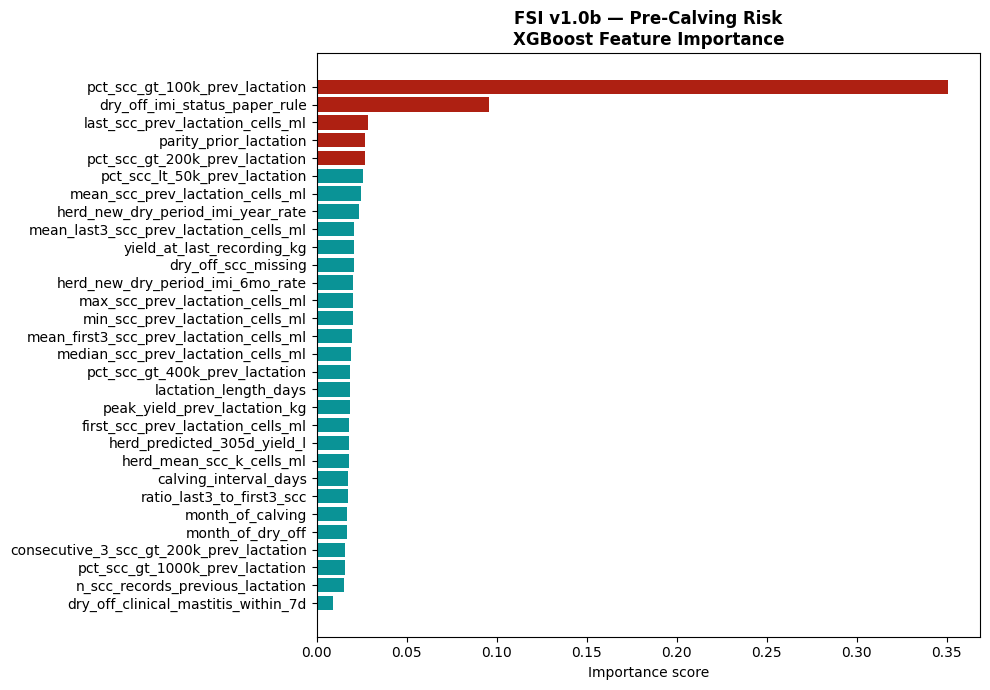


Calculating SHAP values...
Plots saved


In [5]:
# ============================================
# FSI v1.0b — Feature Importance + SHAP
# ============================================

# Feature importance
fi_b = pd.DataFrame({
    'feature': X_imputed.columns,
    'importance': xgb_b.feature_importances_
}).sort_values('importance', ascending=False)

print("TOP 10 FEATURE IMPORTANCES:")
print(fi_b.head(10).to_string(index=False))

# Plot importance
plt.figure(figsize=(10,7))
colors = ['#AE2012' if i < 5 else '#0A9396'
          for i in range(len(fi_b))]
plt.barh(fi_b['feature'], fi_b['importance'], color=colors)
plt.xlabel('Importance score')
plt.title('FSI v1.0b — Pre-Calving Risk\nXGBoost Feature Importance',
          fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('FSI_v1b_importance.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# SHAP
print("\nCalculating SHAP values...")
explainer_b = shap.TreeExplainer(xgb_b)
shap_values_b = explainer_b.shap_values(X_test)

plt.figure(figsize=(10,8))
shap.summary_plot(shap_values_b, X_test, show=False)
plt.title("FSI v1.0b — SHAP Summary\nPre-Calving Risk Prediction",
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('FSI_v1b_SHAP.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Plots saved")

In [6]:
# ============================================
# FSI v1.0b — Cross Validation
# ============================================

print("Running 5-fold cross validation...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'f1':                make_scorer(f1_score),
    'roc_auc':           'roc_auc',
}

xgb_cv_b = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

results_b = cross_validate(xgb_cv_b, X_imputed, y,
                           cv=cv,
                           scoring=scoring,
                           return_train_score=False)

print("============================================")
print("FSI v1.0b — 5-Fold Cross Validation Results")
print("Pre-Calving Risk Prediction")
print("============================================")
print(f"Balanced Accuracy: {results_b['test_balanced_accuracy'].mean():.4f} "
      f"± {results_b['test_balanced_accuracy'].std():.4f}")
print(f"AUC-ROC:           {results_b['test_roc_auc'].mean():.4f} "
      f"± {results_b['test_roc_auc'].std():.4f}")
print(f"F1 Score:          {results_b['test_f1'].mean():.4f} "
      f"± {results_b['test_f1'].std():.4f}")

print("\nPer-fold balanced accuracy:")
for i, score in enumerate(results_b['test_balanced_accuracy']):
    print(f"  Fold {i+1}: {score:.4f}")

# Save model
import joblib
joblib.dump(xgb_b, 'FSI_v1b_precalving_model.pkl')
print("\nModel saved: FSI_v1b_precalving_model.pkl")

Running 5-fold cross validation...
FSI v1.0b — 5-Fold Cross Validation Results
Pre-Calving Risk Prediction
Balanced Accuracy: 0.6656 ± 0.0120
AUC-ROC:           0.7274 ± 0.0088
F1 Score:          0.4253 ± 0.0166

Per-fold balanced accuracy:
  Fold 1: 0.6444
  Fold 2: 0.6649
  Fold 3: 0.6674
  Fold 4: 0.6701
  Fold 5: 0.6813

Model saved: FSI_v1b_precalving_model.pkl


In [8]:
# ============================================
# FSI v1.0b — Save Everything to Drive
# ============================================

import shutil
import json
import os

# Performance summary
performance_b = {
    'model': 'XGBoost',
    'module': 'FSI v1.0b — Pre-Calving Risk Prediction',
    'dataset': 'Synthetic Thompson 2023 Post-Calving SCC',
    'n_records': 10000,
    'n_features': 30,
    'balanced_accuracy': 0.6656,
    'balanced_accuracy_std': 0.0120,
    'auc_roc': 0.7274,
    'auc_roc_std': 0.0088,
    'f1_score': 0.4253,
    'f1_std': 0.0166,
    'top_predictors': [
        'pct_scc_gt_100k_prev_lactation',
        'dry_off_imi_status_paper_rule',
        'last_scc_prev_lactation_cells_ml',
        'parity_prior_lactation',
        'pct_scc_gt_200k_prev_lactation'
    ],
    'key_findings': [
        'Chronic subclinical SCC elevation more predictive than peak values',
        'Dry-off IMI status is strongest binary predictor',
        'Older cows consistently higher risk',
        'Herd IMI rate shows counterintuitive protective effect',
        'Pre-calving prediction achievable at 72.7% AUC-ROC'
    ],
    'prediction_horizon': '60-90 days before calving'
}

with open('FSI_v1b_performance.json', 'w') as f:
    json.dump(performance_b, f, indent=2)

# Ensure the target directory exists in Google Drive
drive_path = '/content/drive/MyDrive/FSI'
os.makedirs(drive_path, exist_ok=True)

# Copy to Drive
files_to_save = [
    'FSI_v1b_precalving_model.pkl',
    'FSI_v1b_performance.json',
    'FSI_v1b_EDA.png',
    'FSI_v1b_importance.png',
    'FSI_v1b_SHAP.png',
]

for f in files_to_save:
    shutil.copy(f, os.path.join(drive_path, f))
    print(f"Saved: {f}")

print("\nAll FSI v1.0b files saved to Drive")

Saved: FSI_v1b_precalving_model.pkl
Saved: FSI_v1b_performance.json
Saved: FSI_v1b_EDA.png
Saved: FSI_v1b_importance.png
Saved: FSI_v1b_SHAP.png

All FSI v1.0b files saved to Drive


In [11]:
import os

# Check if the path exists since Drive appears to be already mounted
drive_path = '/content/drive/MyDrive/FSI'

if os.path.exists(drive_path):
    print("Drive is accessible!")
    print("Files found in Drive:", os.listdir(drive_path))
else:
    print(f"Directory {drive_path} not found.")
    print("Current contents of MyDrive:", os.listdir('/content/drive/MyDrive') if os.path.exists('/content/drive/MyDrive') else "MyDrive not accessible")

Drive is accessible!
Files found in Drive: ['FSI_v1b_importance.png', 'FSI_v1b_performance.json', 'FSI_v1b_SHAP.png', 'FSI_v1b_precalving_model.pkl', 'FSI_v1b_EDA.png']


In [14]:
from google.colab import drive
import os
import shutil

# Using a different mount point to avoid the 'directory not empty' error
target_mount = '/content/gdrive'
drive.mount(target_mount, force_remount=True)

# Define the source files and the new destination
source_files = ['FSI_v1b_precalving_model.pkl', 'FSI_v1b_performance.json', 'FSI_v1b_EDA.png', 'FSI_v1b_importance.png', 'FSI_v1b_SHAP.png']
drive_fsi_path = os.path.join(target_mount, 'MyDrive', 'FSI')

os.makedirs(drive_fsi_path, exist_ok=True)

print("Copying files to fresh mount...")
for f in source_files:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(drive_fsi_path, f))
        print(f"Synced: {f}")

print(f"\nSuccess! Please check the 'FSI' folder in your Google Drive browser tab now.")

Mounted at /content/gdrive
Copying files to fresh mount...
Synced: FSI_v1b_precalving_model.pkl
Synced: FSI_v1b_performance.json
Synced: FSI_v1b_EDA.png
Synced: FSI_v1b_importance.png
Synced: FSI_v1b_SHAP.png

Success! Please check the 'FSI' folder in your Google Drive browser tab now.
